In [1]:
from ultralytics import YOLO
import shutil
ROOT = "../"
DATA_YAML = "/home/sagemaker-user/dataset/data.yaml"

import warnings
import os
warnings.filterwarnings("ignore")
os.environ["PYTHONWARNINGS"] = "ignore"

import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [2]:
import threading
import time

def keep_alive():
    while True:
        time.sleep(300)  # every 5 mins
        print(".", end="", flush=True)

t = threading.Thread(target=keep_alive, daemon=True)
t.start()

# YOLOv11 Nano (from scratch) training

In [2]:
import torch
import gc
from ultralytics import YOLO

# Clean memory before the training
gc.collect()
torch.cuda.empty_cache()
print(f"GPU memory free: {torch.cuda.mem_get_info()[0]/1e9:.2f}GB")

model = YOLO("yolo11n.yaml")
model.train(
  data=DATA_YAML,
  epochs=250,
  imgsz=640,
  batch=16,
  workers=4,
    
  optimizer="AdamW",
  lr0=0.001,
  weight_decay=0.0001,
  warmup_epochs = 3,
  cos_lr=True,
    
  patience=30,

  # Augmentation
  hsv_s=0.3,
  hsv_v=0.15,
  fliplr=0.5,
  mosaic=0.5,
  translate=0.1,
  scale=0.3,
    
  project="/home/sagemaker-user/runs",
  name="yolov11n-scratch",
)


shutil.copy("/home/sagemaker-user/runs/yolov11n-scratch/weights/best.pt", ROOT + "models/yolov11n-scratch.pt")


GPU memory free: 12.62GB


New https://pypi.org/project/ultralytics/8.4.51 available 😃 Update with 'pip install -U ultralytics'


Ultralytics 8.3.0 🚀 Python-3.12.13 torch-2.2.2+cu121 CUDA:0 (Tesla T4, 14913MiB)


engine/trainer: task=detect, mode=train, model=yolo11n.yaml, data=/home/sagemaker-user/dataset/data.yaml, epochs=250, time=None, patience=30, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=4, project=/home/sagemaker-user/runs, name=yolov11n-scratch, exist_ok=False, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=True, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes=True, line_width=None, format=torch

Overriding model.yaml nc=80 with nc=6


...

     15/250      2.57G      1.981      2.946      1.707         14        640: 100%|█████████▉| 459/460 [02:22<00:00,  3.21it/s]

     15/250      2.57G      1.981      2.946      1.707         14        640: 100%|██████████| 460/460 [02:22<00:00,  3.16it/s]

     15/250      2.57G      1.981      2.946      1.707         14        640: 100%|██████████| 460/460 [02:22<00:00,  3.22it/s]

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95):   0%|          | 0/50 [00:00<?, ?it/s]

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95):   2%|▏         | 1/50 [00:00<00:27,  1.79it/s]

# Resuming the training after sagemaker crash
- It actually crashed multiple times.. so we are resuming from the latest checkpoint

In [3]:
import torch
import gc
from ultralytics import YOLO

model = YOLO("/home/sagemaker-user/runs/yolov11n-scratch/weights/last.pt")
model.train(resume=True)

New https://pypi.org/project/ultralytics/8.4.51 available 😃 Update with 'pip install -U ultralytics'


Ultralytics 8.3.0 🚀 Python-3.12.13 torch-2.2.2+cu121 CUDA:0 (Tesla T4, 14913MiB)


engine/trainer: task=detect, mode=train, model=/home/sagemaker-user/runs/yolov11n-scratch/weights/last.pt, data=/home/sagemaker-user/dataset/data.yaml, epochs=250, time=None, patience=30, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=4, project=/home/sagemaker-user/runs, name=yolov11n-scratch2, exist_ok=False, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=True, close_mosaic=10, resume=/home/sagemaker-user/runs/yolov11n-scratch/weights/last.pt, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=Fals


                   from  n    params  module                                       arguments                     


  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 


...

val: Scanning /home/sagemaker-user/dataset/valid/labels.cache... 1576 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1576/1576 [00:00<?, ?it/s]

val: WARNING ⚠️ /home/sagemaker-user/dataset/valid/images/190_jpg.rf.074dab6dafb9d61232aeb760fb58eb23.jpg: 1 duplicate labels removed
val: WARNING ⚠️ /home/sagemaker-user/dataset/valid/images/248_jpg.rf.cd4818fc841469bfb4eadb6786b392da.jpg: 1 duplicate labels removed
val: WARNING ⚠️ /home/sagemaker-user/dataset/valid/images/286_jpg.rf.4ed7044ad9e72671b21816fbec8dc253.jpg: 1 duplicate labels removed
val: WARNING ⚠️ /home/sagemaker-user/dataset/valid/images/286_jpg.rf.b15a2a7690e40091627b4188ac9afda9.jpg: 1 duplicate labels removed


Plotting labels to /home/sagemaker-user/runs/yolov11n-scratch2/labels.jpg... 


optimizer: AdamW(lr=0.001, momentum=0.937) with parameter groups 81 weight(decay=0.0), 88 weight(decay=0.0001), 87 bias(decay=0.0)


AssertionError: /home/sagemaker-user/runs/yolov11n-scratch/weights/last.pt training to 250 epochs is finished, nothing to resume.
Start a new training without resuming, i.e. 'yolo train model=/home/sagemaker-user/runs/yolov11n-scratch/weights/last.pt'

# Visualise the training 

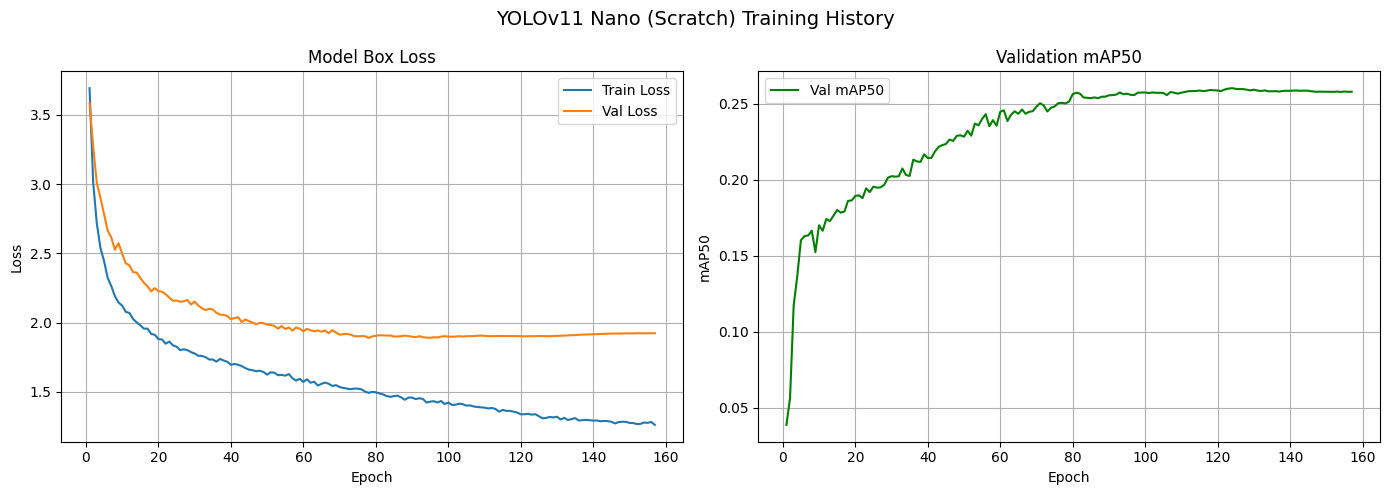

In [4]:
shutil.copy("/home/sagemaker-user/runs/yolov11n-scratch/weights/best.pt", ROOT + "models/yolov11n-scratch.pt") # Copy the best model
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
results = pd.read_csv("/home/sagemaker-user/runs/yolov11n-scratch/results.csv")
results.columns = results.columns.str.strip()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
ax1.plot(results["epoch"], results["train/box_loss"], label="Train Loss")
ax1.plot(results["epoch"], results["val/box_loss"], label="Val Loss")
ax1.set_title("Model Box Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True)

# mAP50 plot
ax2.plot(results["epoch"], results["metrics/mAP50(B)"], label="Val mAP50", color="green")
ax2.set_title("Validation mAP50")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("mAP50")
ax2.legend()
ax2.grid(True)

plt.suptitle("YOLOv11 Nano (Scratch) Training History", fontsize=14)
plt.tight_layout()
plt.show()

# The model accuracy on Train, Val and Test datasets

In [5]:
model = YOLO("../models/yolov11n-scratch.pt")
train_metrics = model.val(split="train")
val_metrics = model.val(split="val")
test_metrics = model.val(split="test")
print(f"Train  mAP@50: {train_metrics.box.map50:.4f}")
print(f"Val  mAP@50: {val_metrics.box.map50:.4f}")
print(f"Test mAP@50: {test_metrics.box.map50:.4f}")

Ultralytics 8.3.0 🚀 Python-3.12.13 torch-2.2.2+cu121 CUDA:0 (Tesla T4, 14913MiB)


YOLO11n summary (fused): 238 layers, 2,583,322 parameters, 0 gradients, 6.3 GFLOPs


val: Scanning /home/sagemaker-user/dataset/train/labels.cache... 7353 images, 0 backgrounds, 0 corrupt: 100%|██████████| 7353/7353 [00:00<?, ?it/s]

val: Scanning /home/sagemaker-user/dataset/train/labels.cache... 7353 images, 0 backgrounds, 0 corrupt: 100%|██████████| 7353/7353 [00:00<?, ?it/s]

train: WARNING ⚠️ /home/sagemaker-user/dataset/train/images/190_jpg.rf.7022c064680bdbee866a35758df1078a.jpg: 1 duplicate labels removed
train: WARNING ⚠️ /home/sagemaker-user/dataset/train/images/264_jpg.rf.0f08bf974f97ac3ec8b86f18ac49236a.jpg: 2 duplicate labels removed
train: WARNING ⚠️ /home/sagemaker-user/dataset/train/images/264_jpg.rf.21a5ebc0fe2f1e01f4c70e95deb3194a.jpg: 2 duplicate labels removed
train: WARNING ⚠️ /home/sagemaker-user/dataset/train/images/308_jpg.rf.00d32b5de0fa24f9c82a3381814cb212.jpg: 1 duplicate labels removed
train: WARNING ⚠️ /home/sagemaker-user/dataset/train/images/315_jpg.rf.8e6cca8d21141ef7daeeb2828b486ad0.jpg: 1 duplicate labels removed
train: WARNING ⚠️ /home/sagemaker-user/dataset/train/images/315_jpg.rf.aaa45f92f900718c247e09ea7dc3f298.jpg: 1 duplicate labels removed
train: WARNING ⚠️ /home/sagemaker-user/dataset/train/images/388_jpg.rf.96974ed6833e13cf10aaa123dc004ddc.jpg: 1 duplicate labels removed
train: WARNING ⚠️ /home/sagemaker-user/dataset/t

...

                  Tape        261        404      0.272      0.191      0.156      0.104


Speed: 0.4ms preprocess, 3.9ms inference, 0.0ms loss, 1.7ms postprocess per image


Results saved to runs/detect/val9


Train  mAP@50: 0.5322
Val  mAP@50: 0.2593
Test mAP@50: 0.2618


.